<a href="https://colab.research.google.com/github/novalrnv/machine_learning/blob/main/JS05/JS05-Tugas-Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab 1 - Klasifikasi Suara Male/Female dengan kNN

## Soal 1

Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara `male` dan `female` pada dataset `voice.csv`.

### Jawaban

In [ ]:
import pandas as pd

data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [ ]:
data.info()
data['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

label
male      1584
female    1584
Name: count, dtype: int64

In [ ]:
# Pisahkan fitur (X) dan label (y), lalu encode label male/female menjadi angka
X = data.drop('label', axis=1)
y = data['label'].map({'male': 1, 'female': 0})

X.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model kNN dengan k=5 (baseline)
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = knn_baseline.predict(X_test_scaled)

print('Akurasi dengan semua fitur (20 fitur):', accuracy_score(y_test, y_pred_baseline))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_baseline))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_baseline))

Akurasi dengan semua fitur (20 fitur): 0.9737118822292324

Confusion Matrix:
 [[435  17]
 [  8 491]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       452
           1       0.97      0.98      0.98       499

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



## Soal 2

Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

### Jawaban

In [ ]:
# Hitung korelasi setiap fitur terhadap label
data_corr = X.copy()
data_corr['label'] = y
korelasi = data_corr.corr()['label'].drop('label').abs().sort_values(ascending=False)
print(korelasi)

meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
centroid    0.337415
meanfreq    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label, dtype: float64


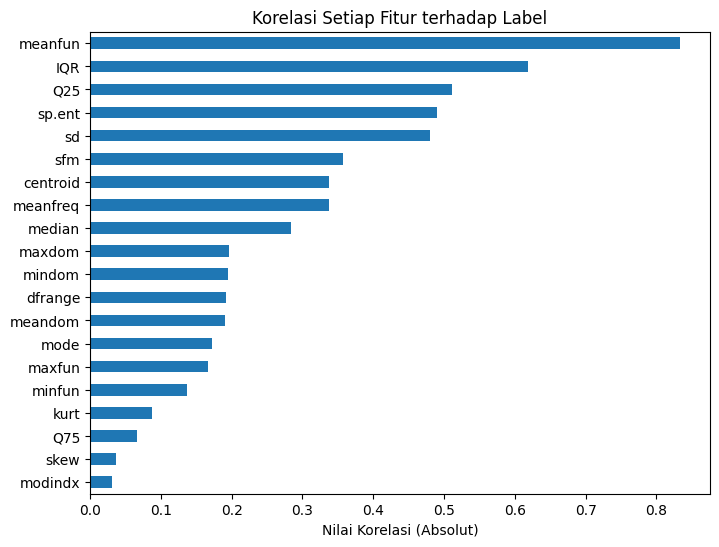

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
korelasi.sort_values().plot(kind='barh')
plt.title('Korelasi Setiap Fitur terhadap Label')
plt.xlabel('Nilai Korelasi (Absolut)')
plt.show()

In [ ]:
# Coba beberapa jumlah fitur teratas (berdasarkan korelasi)
fitur_terurut = korelasi.index.tolist()

hasil_akurasi = []
daftar_n = [1, 2, 3, 5, 8, 10, 20]
for n in daftar_n:
    fitur_terpilih = fitur_terurut[:n]

    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X[fitur_terpilih], y, test_size=0.3, random_state=42)

    scaler_f = StandardScaler()
    X_train_f = scaler_f.fit_transform(X_train_f)
    X_test_f = scaler_f.transform(X_test_f)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_f, y_train_f)
    acc = model.score(X_test_f, y_test_f)

    hasil_akurasi.append(acc)
    print(f'Jumlah fitur: {n:2d} -> Akurasi: {acc:.4f} -> Fitur: {fitur_terpilih}')

Jumlah fitur:  1 -> Akurasi: 0.9443 -> Fitur: ['meanfun']
Jumlah fitur:  2 -> Akurasi: 0.9674 -> Fitur: ['meanfun', 'IQR']
Jumlah fitur:  3 -> Akurasi: 0.9706 -> Fitur: ['meanfun', 'IQR', 'Q25']
Jumlah fitur:  5 -> Akurasi: 0.9800 -> Fitur: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd']
Jumlah fitur:  8 -> Akurasi: 0.9811 -> Fitur: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq']
Jumlah fitur: 10 -> Akurasi: 0.9790 -> Fitur: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median', 'maxdom']
Jumlah fitur: 20 -> Akurasi: 0.9737 -> Fitur: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median', 'maxdom', 'mindom', 'dfrange', 'meandom', 'mode', 'maxfun', 'minfun', 'kurt', 'Q75', 'skew', 'modindx']


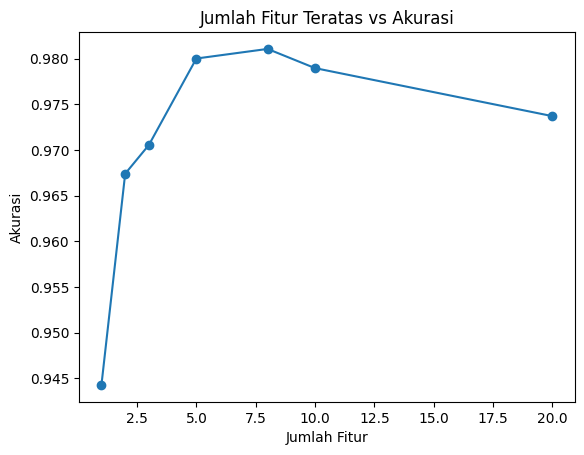

In [ ]:
plt.plot(daftar_n, hasil_akurasi, marker='o')
plt.title('Jumlah Fitur Teratas vs Akurasi')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')
plt.show()

**Jawaban:** Fitur yang digunakan untuk mendapatkan hasil terbaik adalah 5 fitur dengan korelasi tertinggi terhadap label, yaitu:

`meanfun`, `IQR`, `Q25`, `sp.ent`, `sd`

Fitur `meanfun` (frekuensi fundamental rata-rata) memiliki korelasi paling tinggi terhadap label suara male/female.

In [ ]:
fitur_optimal = fitur_terurut[:5]
print('Fitur optimal yang digunakan:', fitur_optimal)

X_opt = X[fitur_optimal]
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X_opt, y, test_size=0.3, random_state=42)

scaler_opt = StandardScaler()
X_train_opt = scaler_opt.fit_transform(X_train_opt)
X_test_opt = scaler_opt.transform(X_test_opt)

Fitur optimal yang digunakan: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd']


## Soal 3

Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai $k$ yang terbaik? Lampirkan grafik analisis dan alasan Anda.

### Jawaban

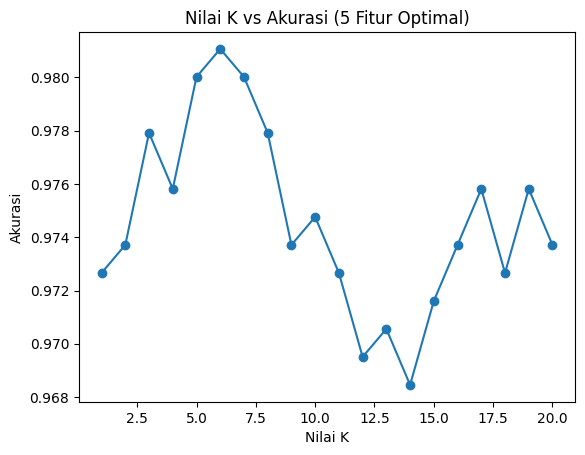

Nilai k terbaik: 6 dengan akurasi: 0.9811


In [ ]:
acc_k = []
for k in range(1, 21):
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train_opt, y_train_opt)
    acc_k.append(model_k.score(X_test_opt, y_test_opt))

plt.plot(range(1, 21), acc_k, marker='o')
plt.title('Nilai K vs Akurasi (5 Fitur Optimal)')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.show()

k_terbaik = acc_k.index(max(acc_k)) + 1
print(f'Nilai k terbaik: {k_terbaik} dengan akurasi: {max(acc_k):.4f}')

In [ ]:
model_final = KNeighborsClassifier(n_neighbors=k_terbaik)
model_final.fit(X_train_opt, y_train_opt)
y_pred_final = model_final.predict(X_test_opt)

print('Akurasi:', accuracy_score(y_test_opt, y_pred_final))
print('Confusion Matrix:\n', confusion_matrix(y_test_opt, y_pred_final))
print('Laporan Klasifikasi:\n', classification_report(y_test_opt, y_pred_final))

Akurasi: 0.9810725552050473
Confusion Matrix:
 [[446   6]
 [ 12 487]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       452
           1       0.99      0.98      0.98       499

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



Berdasarkan grafik "Nilai K vs Akurasi" di atas, nilai $k$ yang memberikan akurasi tertinggi pada data testing adalah **k = 6**, dengan akurasi sekitar **98.1%**.

**Alasan:** Nilai $k$ yang terlalu kecil (seperti k=1) membuat model terlalu sensitif terhadap noise (data individual yang tidak representatif), sehingga mudah overfit. Sebaliknya, nilai $k$ yang terlalu besar membuat batas keputusan terlalu umum/halus sehingga dapat mengabaikan pola lokal yang penting.